## Step 1: Dataset Loading & Exploratory Data Analysis


### Load & Filter the Dataset


In [116]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv")

In [117]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1067371, 8)


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [119]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


------
--------

In [120]:
df = df[df["Country"] == "United Kingdom"]
print("After Country Filter:", df.shape)

After Country Filter: (981330, 8)


----
--------

In [121]:
print(df["Customer ID"].isnull().sum())

240029


In [122]:
df = df.dropna(subset=["Customer ID"])
print("Rows Remaining:", df.shape[0])

Rows Remaining: 741301


----------
---------

In [123]:
before = df.shape[0]
df = df[df["Quantity"] > 0]
after = df.shape[0]

print("Rows Dropped:", before - after)
print("Rows Remaining:", after)

Rows Dropped: 16005
Rows Remaining: 725296


-----
-------

In [124]:
before = df.shape[0]
df = df[df["Price"] > 0]
after = df.shape[0]

print("Rows Dropped:", before - after)
print("Rows Remaining:", after)

Rows Dropped: 46
Rows Remaining: 725250


------
----------

In [125]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [126]:
print(df[["Quantity", "Price", "TotalPrice"]].head())

   Quantity  Price  TotalPrice
0        12   6.95        83.4
1        12   6.75        81.0
2        12   6.75        81.0
3        48   2.10       100.8
4        24   1.25        30.0


### Univariate Analysis


In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Histogram of Quantity

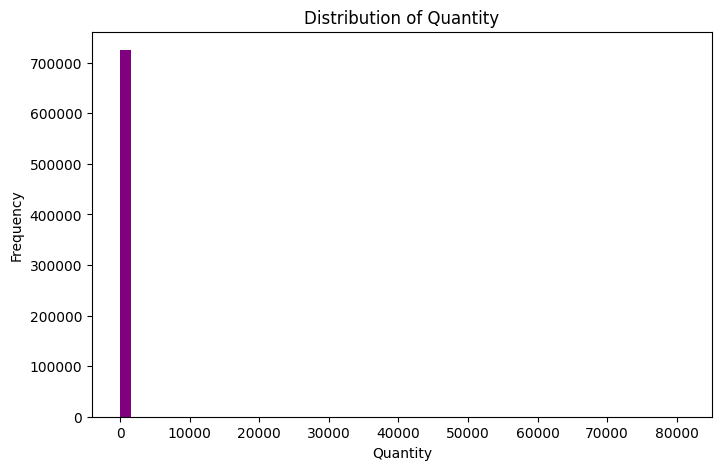

In [271]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=50, color='purple')
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Observation

- Most purchases have small quantities.
- Very large quantities are rare.

##### Histogram of Unit Price (Log Scale)

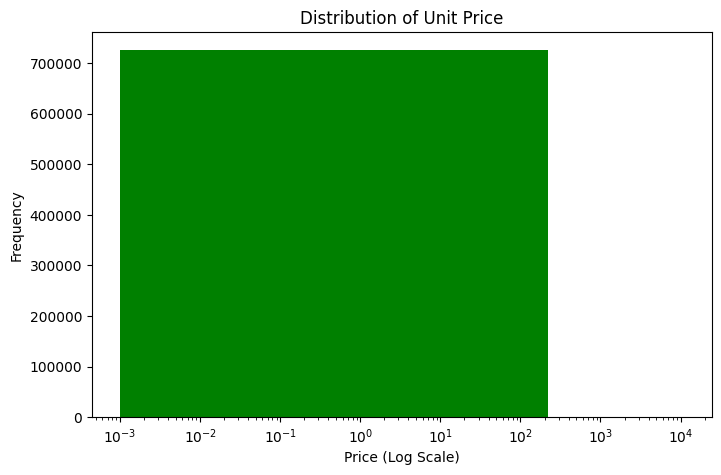

In [272]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=50, color='green')
plt.xscale("log")
plt.title("Distribution of Unit Price")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Frequency")
plt.show()

Observation

- Most products have low prices.
- Few expensive products exist.

##### Histogram of TotalPrice (Log Scale)

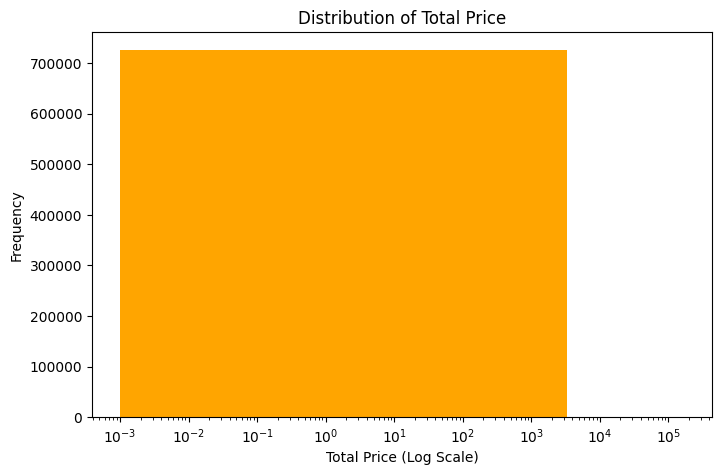

In [130]:
plt.figure(figsize=(8,5))
plt.hist(df["TotalPrice"], bins=50, color='orange')
plt.xscale("log")
plt.title("Distribution of Total Price")
plt.xlabel("Total Price (Log Scale)")
plt.ylabel("Frequency")
plt.show()

Observation

- Most orders have low total values.
- Few orders have very high values.

----------
-----------

In [131]:
df_original = pd.read_csv("online_retail_II.csv")

top10 = df_original["Country"].value_counts().head(10)
print(top10)

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


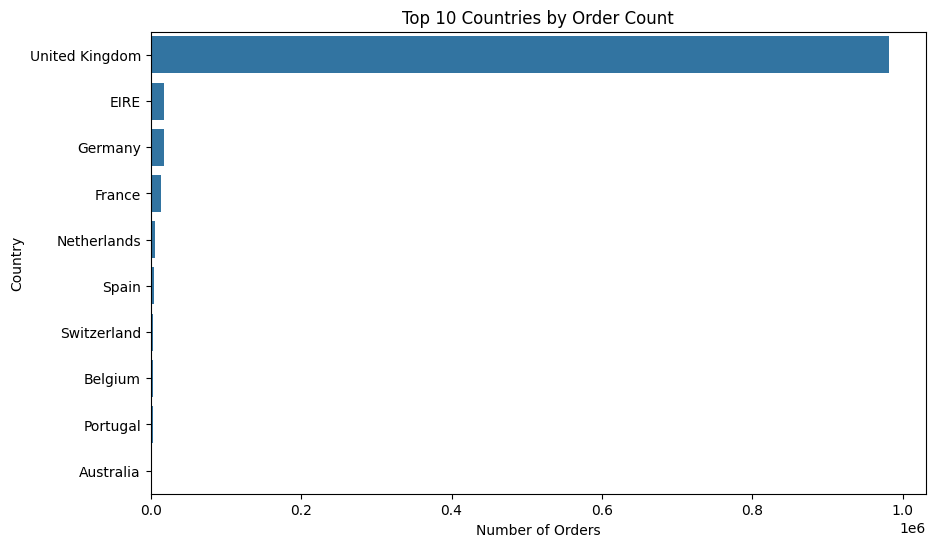

In [132]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_original,
    y="Country",
    order=top10.index
)

plt.title("Top 10 Countries by Order Count")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.show()

Observation

- United Kingdom has the highest number of orders.
- Other countries contribute much fewer orders.

------ 
-----

In [133]:
df_original["InvoiceDate"] = pd.to_datetime(df_original["InvoiceDate"])

df_original["Month"] = df_original["InvoiceDate"].dt.to_period("M")

In [134]:
monthly_orders = df_original.groupby("Month").size()

monthly_orders

Month
2009-12    45228
2010-01    31555
2010-02    29388
2010-03    41511
2010-04    34057
2010-05    35323
2010-06    39983
2010-07    33383
2010-08    33306
2010-09    42091
2010-10    59098
2010-11    78015
2010-12    65004
2011-01    35147
2011-02    27707
2011-03    36748
2011-04    29916
2011-05    37030
2011-06    36874
2011-07    39518
2011-08    35284
2011-09    50226
2011-10    60742
2011-11    84711
2011-12    25526
Freq: M, dtype: int64

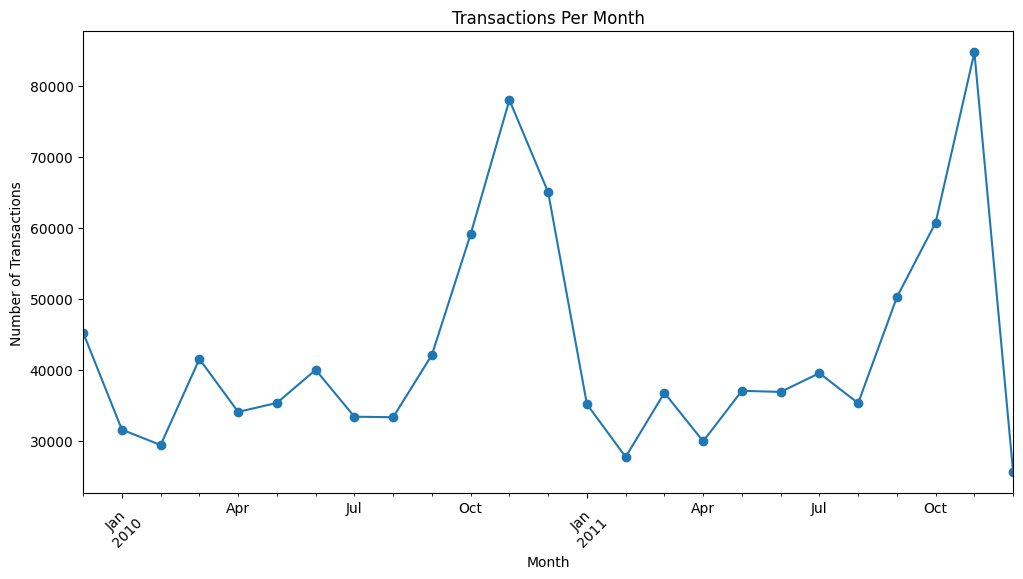

In [135]:
plt.figure(figsize=(12,6))

monthly_orders.plot(marker="o")

plt.title("Transactions Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

Observation:

- Transaction volume generally increases towards the end of the year.
- Significant spikes are usually observed in November and December, likely due to holiday shopping and Christmas sales.
- The beginning of the year typically has comparatively fewer transactions.

### Customer-Level Analysis

In [136]:
customer_spend = df.groupby("Customer ID")["TotalPrice"].sum().reset_index()
customer_spend.columns = ["Customer ID", "TotalSpend"]

customer_spend.head()

,Customer ID,TotalSpend
0,12346.0,77556.46
1,12608.0,415.79
2,12745.0,723.85
3,12746.0,254.55
4,12747.0,9276.54


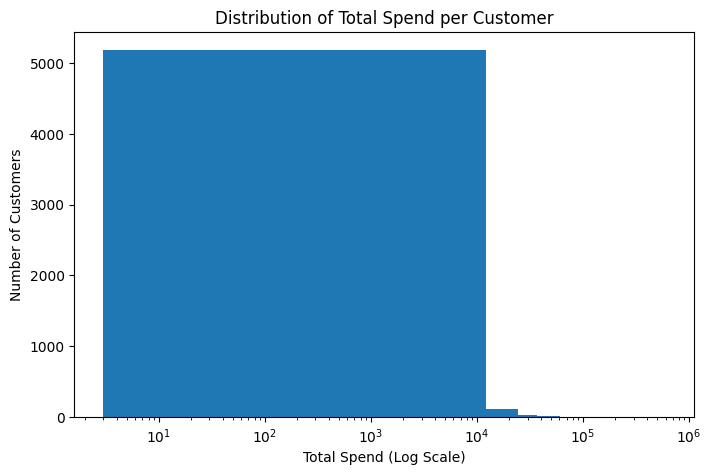

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(customer_spend["TotalSpend"], bins=50)
plt.xscale("log")

plt.title("Distribution of Total Spend per Customer")
plt.xlabel("Total Spend (Log Scale)")
plt.ylabel("Number of Customers")

plt.show()

Observation

- Most customers spend relatively small amounts.
- A few customers spend very large amounts.

--------
--------

In [138]:
customer_orders = df.groupby("Customer ID")["Invoice"].nunique().reset_index()

customer_orders.columns = ["Customer ID", "OrderCount"]

customer_orders.head()

,Customer ID,OrderCount
0,12346.0,12
1,12608.0,1
2,12745.0,2
3,12746.0,1
4,12747.0,26


In [139]:
top10_buyers = customer_orders.sort_values(
    by="OrderCount",
    ascending=False
).head(10)

top10_buyers

,Customer ID,OrderCount
5,12748.0,336
4907,17841.0,211
2427,15311.0,208
270,13089.0,203
1742,14606.0,192
4915,17850.0,155
5165,18102.0,145
857,13694.0,143
2178,15061.0,127
1666,14527.0,122


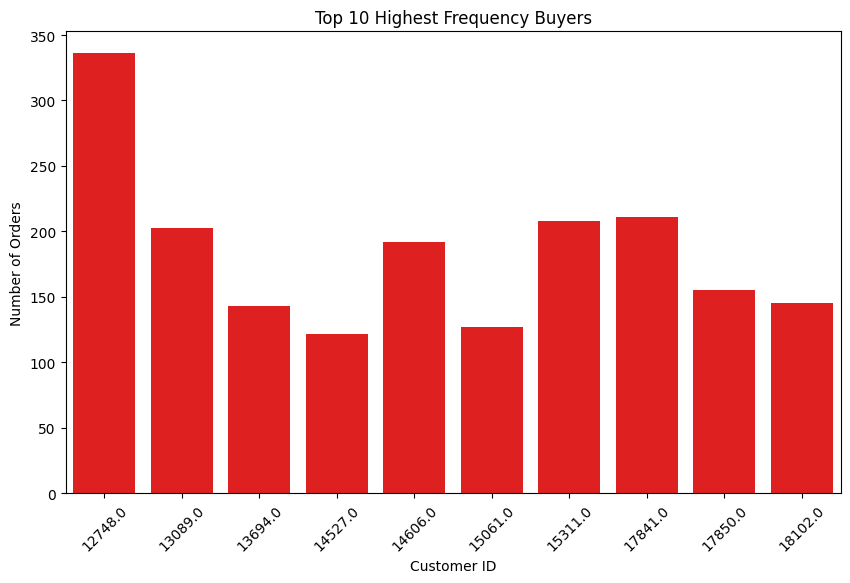

In [274]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_buyers,
    x="Customer ID",
    y="OrderCount",
    color='red'
)

plt.title("Top 10 Highest Frequency Buyers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

------------
--------------

In [141]:
unique_customers = df["Customer ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 5350


In [142]:
total_revenue = customer_spend["TotalSpend"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 14723147.517


In [143]:
customer_spend = customer_spend.sort_values(
    by="TotalSpend",
    ascending=False
)

customer_spend.head()

,Customer ID,TotalSpend
5165,18102.0,608821.65
4527,17450.0,246973.09
857,13694.0,196482.81
4585,17511.0,175603.55
3542,16446.0,168472.50


In [144]:
customer_spend["CumulativeRevenue"] = customer_spend["TotalSpend"].cumsum()

customer_spend.head()

,Customer ID,TotalSpend,CumulativeRevenue
5165,18102.0,608821.65,608821.65
4527,17450.0,246973.09,855794.74
857,13694.0,196482.81,1052277.55
4585,17511.0,175603.55,1227881.10
3542,16446.0,168472.50,1396353.60


In [145]:
customer_spend["RevenuePercent"] = (
    customer_spend["CumulativeRevenue"] / total_revenue
) * 100

customer_spend.head()

,Customer ID,TotalSpend,CumulativeRevenue,RevenuePercent
5165,18102.0,608821.65,608821.65,4.135132
4527,17450.0,246973.09,855794.74,5.812580
857,13694.0,196482.81,1052277.55,7.147096
4585,17511.0,175603.55,1227881.10,8.339800
3542,16446.0,168472.50,1396353.60,9.484070


In [146]:
customers_80 = customer_spend[
    customer_spend["RevenuePercent"] <= 80
]

customers_80.head()

,Customer ID,TotalSpend,CumulativeRevenue,RevenuePercent
5165,18102.0,608821.65,608821.65,4.135132
4527,17450.0,246973.09,855794.74,5.812580
857,13694.0,196482.81,1052277.55,7.147096
4585,17511.0,175603.55,1227881.10,8.339800
3542,16446.0,168472.50,1396353.60,9.484070


In [147]:
percent_customers = (
    len(customers_80) /
    len(customer_spend)
) * 100

print("Percentage of Customers Driving 80% Revenue:")
print(round(percent_customers,2), "%")

Percentage of Customers Driving 80% Revenue:
24.3 %


In [148]:
print("Total Customers:", len(customer_spend))
print("Customers contributing 80% Revenue:", len(customers_80))
print("Percentage:", round(percent_customers,2), "%")

Total Customers: 5350
Customers contributing 80% Revenue: 1300
Percentage: 24.3 %


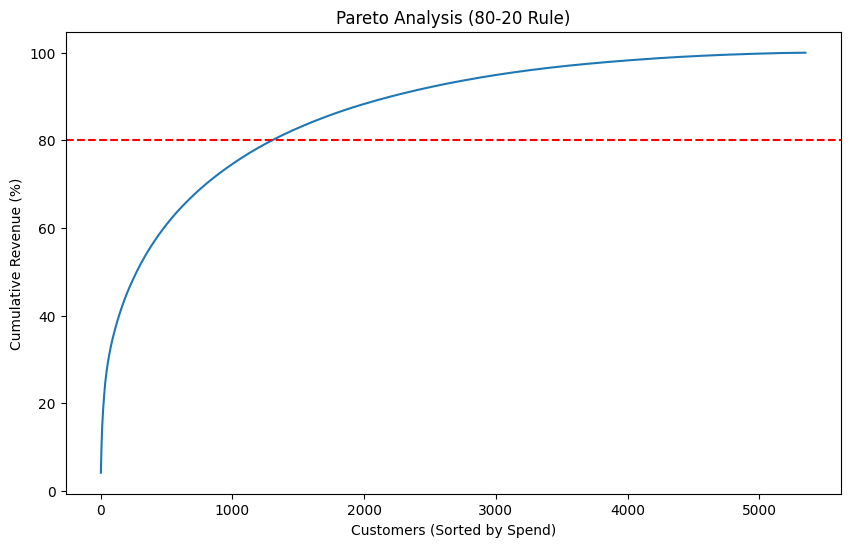

In [149]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(customer_spend)+1),
    customer_spend["RevenuePercent"]
)

plt.axhline(80, color="red", linestyle="--")

plt.title("Pareto Analysis (80-20 Rule)")
plt.xlabel("Customers (Sorted by Spend)")
plt.ylabel("Cumulative Revenue (%)")

plt.show()

## Step 2: RFM Feature Engineering & Preprocessing


### Build the RFM Table


In [150]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Reference date
reference_date = pd.Timestamp("2011-12-31")

# RFM calculation
recency = (reference_date - df.groupby("Customer ID")["InvoiceDate"].max()).dt.days
frequency = df.groupby("Customer ID")["Invoice"].nunique()
monetary = df.groupby("Customer ID")["TotalPrice"].sum()

# Create RFM table
rfm_df = pd.DataFrame({
    "CustomerID": recency.index,
    "Recency": recency.values,
    "Frequency": frequency.values,
    "Monetary": monetary.values
})

print(rfm_df.head())

print("\nSummary Statistics:")
print(rfm_df.describe())

print("\nSkewness:")
print(rfm_df[["Recency","Frequency","Monetary"]].skew())

# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_df[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency","Frequency","Monetary"]
)

print("\nScaled Data:")
print(rfm_scaled_df.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      346         12  77556.46
1     12608.0      425          1    415.79
2     12745.0      507          2    723.85
3     12746.0      561          1    254.55
4     12747.0       23         26   9276.54

Summary Statistics:
         CustomerID      Recency    Frequency       Monetary
count   5350.000000  5350.000000  5350.000000    5350.000000
mean   15557.362617   223.546168     6.269346    2751.990190
std     1581.161762   209.973818    11.995550   12080.466564
min    12346.000000    21.000000     1.000000       2.950000
25%    14191.250000    46.000000     1.000000     336.167500
50%    15565.500000   119.000000     3.000000     849.910000
75%    16922.750000   402.000000     7.000000    2214.905000
max    18287.000000   759.000000   336.000000  608821.650000

Skewness:
Recency       0.871993
Frequency    10.433090
Monetary     28.971352
dtype: float64

Scaled Data:
    Recency  Frequency  Monetary
0  0.583241   0.477776  

Example observations:

- Recency: Wide range of values; many customers purchased recently, while some have not purchased for a long time.
- Frequency: Highly right-skewed; most customers place only a few orders, while a small number place many orders.
- Monetary: Strongly right-skewed; a few customers contribute very high spending compared to the majority.

### Handle Outliers

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Recency

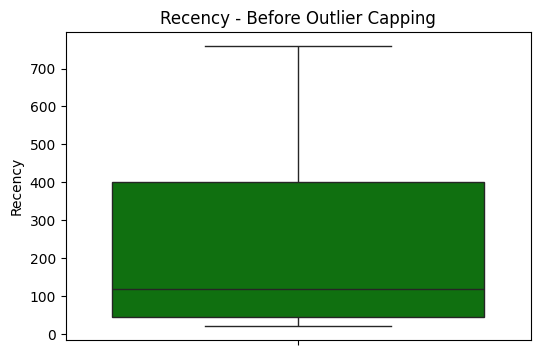

In [152]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Recency"], color='green')
plt.title("Recency - Before Outlier Capping")
plt.show()

Interpretation

- Box ke bahar jo points dikhte hain wo outliers hain.
- Kuch customers bahut purane (inactive) hain, isliye Recency zyada hai.

##### Frequency

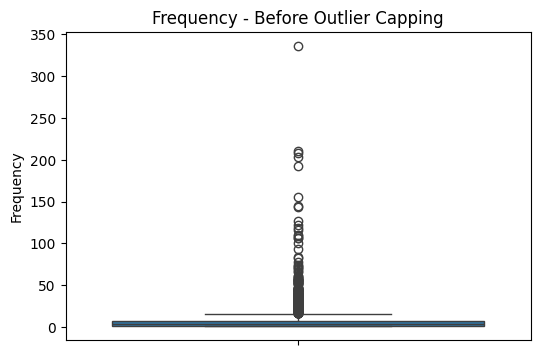

In [153]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Frequency"])
plt.title("Frequency - Before Outlier Capping")
plt.show()

Interpretation

- Kuch customers ne bahut zyada orders place kiye hain.
- Ye high-frequency buyers outliers ke roop me dikhte hain.

##### Monetary

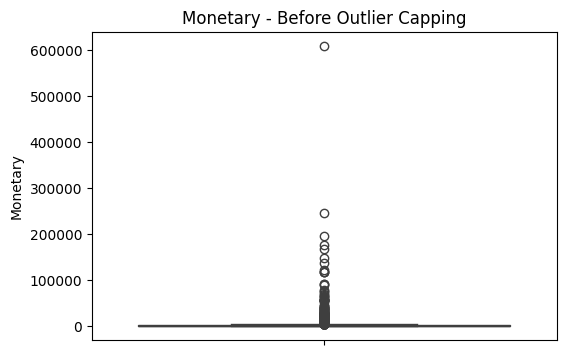

In [154]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Monetary"])
plt.title("Monetary - Before Outlier Capping")
plt.show()

Interpretation

- Kuch customers ka spending bahut high hai.
- Monetary feature usually sabse zyada right-skewed hota hai.

--------------
------

In [155]:
columns = ["Recency", "Frequency", "Monetary"]

for col in columns:
    
    Q1 = rfm_df[col].quantile(0.25)
    Q3 = rfm_df[col].quantile(0.75)

    IQR = Q3 - Q1

    upper_limit = Q3 + (3 * IQR)

    rfm_df[col] = rfm_df[col].clip(upper=upper_limit)

    print(f"{col}")
    print("Upper Limit:", round(upper_limit,2))
    print()

Recency
Upper Limit: 1470.0

Frequency
Upper Limit: 25.0

Monetary
Upper Limit: 7851.12



Interpretation

- Extreme values ko remove nahi kiya gaya.
- Sirf bahut bade values ko upper limit tak cap kiya gaya.
- Is process ko Winsorization kehte hain.

----------
--------

##### Recency

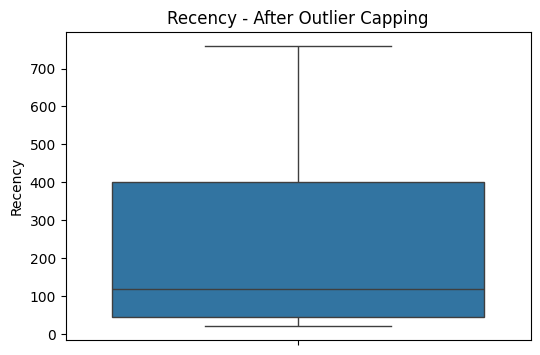

In [156]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Recency"])
plt.title("Recency - After Outlier Capping")
plt.show()

Interpretation

- Extreme Recency values reduce ho gayi hain.
- Distribution zyada balanced lag raha hai.

##### Frequency

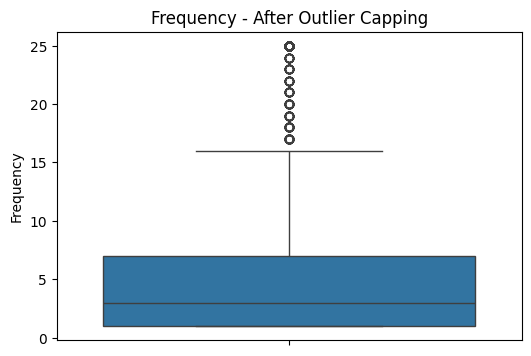

In [157]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Frequency"])
plt.title("Frequency - After Outlier Capping")
plt.show()

Interpretation

- High-frequency customers ab threshold ke andar aa gaye hain.
- Data ka spread improve hua hai.

##### Monetary

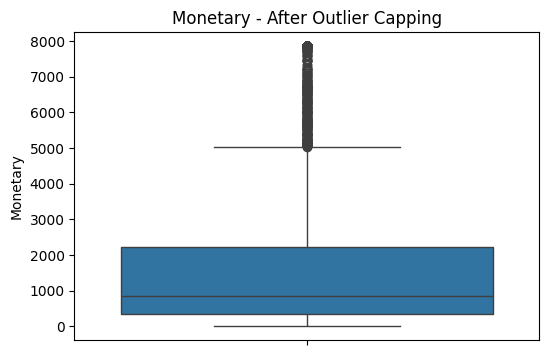

In [158]:
plt.figure(figsize=(6,4))
sns.boxplot(y=rfm_df["Monetary"])
plt.title("Monetary - After Outlier Capping")
plt.show()

Interpretation

- Bahut high spending values cap ho gayi hain.
- Monetary distribution ab clustering ke liye zyada suitable hai.

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_df[["Recency", "Frequency", "Monetary"]]
)

In [160]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.583241,1.101349,2.810103
1,0.959513,-0.738505,-0.626310
2,1.350075,-0.571246,-0.483933
3,1.607274,-0.738505,-0.700831
4,-0.955190,3.275722,2.810103


### Transform Skewed Features


In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

##### Recency

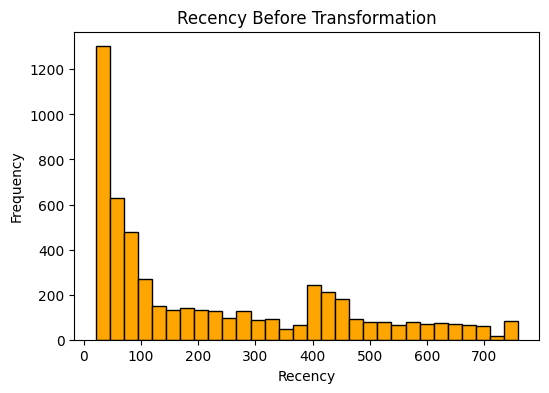

In [263]:
plt.figure(figsize=(6,4))
plt.hist(rfm_df["Recency"], bins=30, edgecolor="black", color='orange')
plt.title("Recency Before Transformation")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

Interpretation:

- Recency may be slightly skewed.
- Since it contains time intervals, we generally do not apply log transformation.

##### Frequency

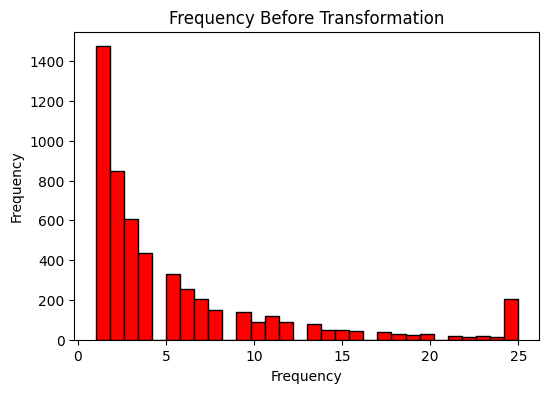

In [264]:
plt.figure(figsize=(6,4))
plt.hist(rfm_df["Frequency"], bins=30, edgecolor="black",  color='red')
plt.title("Frequency Before Transformation")
plt.xlabel("Frequency")
plt.ylabel("Frequency")
plt.show()

Interpretation:

- Most customers have very few orders.
- A small number of customers have many orders, causing right skewness.

##### Monetary

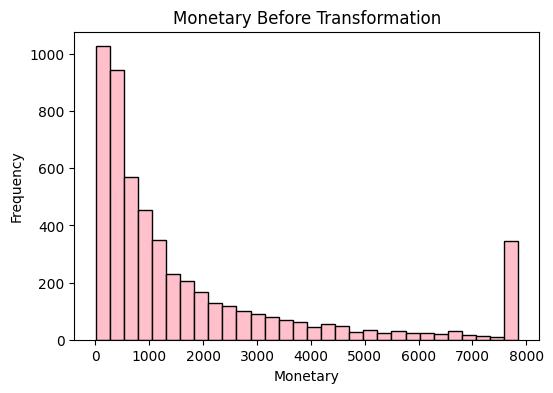

In [265]:
plt.figure(figsize=(6,4))
plt.hist(rfm_df["Monetary"], bins=30, edgecolor="black", color='pink')
plt.title("Monetary Before Transformation")
plt.xlabel("Monetary")
plt.ylabel("Frequency")
plt.show()

Interpretation:

- Most customers spend relatively little.
- A few customers spend very large amounts, creating a highly right-skewed distribution.

---------
--------

In [165]:
rfm_df["Frequency_Log"] = np.log1p(rfm_df["Frequency"])
rfm_df["Monetary_Log"] = np.log1p(rfm_df["Monetary"])

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Frequency_Log,Monetary_Log
0,12346.0,346,12,7851.1175,2.564949,8.968539
1,12608.0,425,1,415.7900,0.693147,6.032582
2,12745.0,507,2,723.8500,1.098612,6.585965
3,12746.0,561,1,254.5500,0.693147,5.543418
4,12747.0,23,25,7851.1175,3.258097,8.968539


In [166]:
rfm_df[["Frequency", "Frequency_Log", "Monetary", "Monetary_Log"]].head()

,Frequency,Frequency_Log,Monetary,Monetary_Log
0,12,2.564949,7851.1175,8.968539
1,1,0.693147,415.7900,6.032582
2,2,1.098612,723.8500,6.585965
3,1,0.693147,254.5500,5.543418
4,25,3.258097,7851.1175,8.968539


In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_df[["Recency", "Frequency_Log", "Monetary_Log"]]
)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.583241,1.351757,1.727116
1,0.959513,-1.108665,-0.561941
2,1.350075,-0.575695,-0.130489
3,1.607274,-1.108665,-0.943324
4,-0.955190,2.262876,1.727116


----------
----------

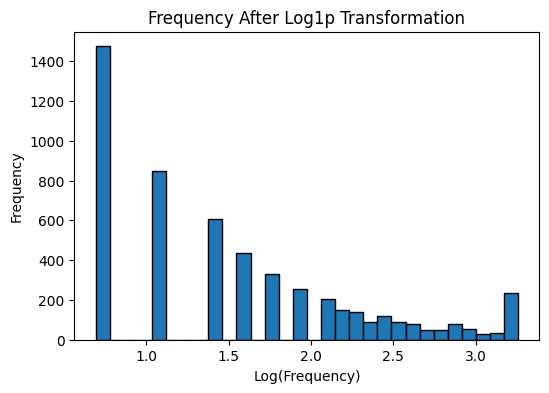

In [168]:
plt.figure(figsize=(6,4))
plt.hist(rfm_df["Frequency_Log"], bins=30, edgecolor="black")
plt.title("Frequency After Log1p Transformation")
plt.xlabel("Log(Frequency)")
plt.ylabel("Frequency")
plt.show()

Interpretation:

- High spending values are compressed.
- The histogram becomes closer to a normal distribution.
- This improves clustering performance.

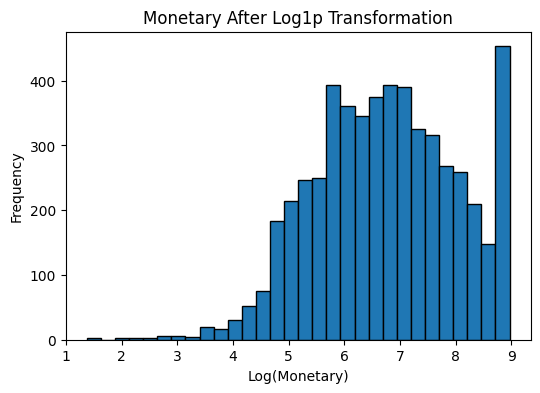

In [169]:
plt.figure(figsize=(6,4))
plt.hist(rfm_df["Monetary_Log"], bins=30, edgecolor="black")
plt.title("Monetary After Log1p Transformation")
plt.xlabel("Log(Monetary)")
plt.ylabel("Frequency")
plt.show()

Interpretation:

- High spending values are compressed.
- The histogram becomes closer to a normal distribution.
- This improves clustering performance.

Interpretation

Frequency

- Before transformation, the distribution was highly right-skewed, with most customers placing only a few orders and a small number placing many orders.
- After applying log1p(), the distribution becomes more symmetrical and less skewed because large values are compressed.

Monetary

- Before transformation, the Monetary feature was also strongly right-skewed due to a few customers with very high spending.
- After the log1p() transformation, the histogram appears more balanced, with reduced skewness and fewer extreme values.

### Scale the Features


In [170]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_df[["Recency", "Frequency_Log", "Monetary_Log"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

print(rfm_scaled.head())

    Recency  Frequency  Monetary
0  0.583241   1.351757  1.727116
1  0.959513  -1.108665 -0.561941
2  1.350075  -0.575695 -0.130489
3  1.607274  -1.108665 -0.943324
4 -0.955190   2.262876  1.727116


Interpretation:

The StandardScaler was applied to the Recency, Frequency_Log, and Monetary_Log features. The resulting rfm_scaled DataFrame contains standardized values that are ready for clustering. Standardization ensures that all features are on the same scale, preventing any single feature from dominating the distance calculations used by clustering algorithms.

-----------
-------

In [171]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

rfm_scaled = pd.DataFrame(
    StandardScaler().fit_transform(
        rfm_df[["Recency", "Frequency_Log", "Monetary_Log"]]
    ),
    columns=["Recency", "Frequency", "Monetary"]
)

print(rfm_scaled.head())

    Recency  Frequency  Monetary
0  0.583241   1.351757  1.727116
1  0.959513  -1.108665 -0.561941
2  1.350075  -0.575695 -0.130489
3  1.607274  -1.108665 -0.943324
4 -0.955190   2.262876  1.727116


----------
----------

In [172]:
print("Mean of Scaled Features:")
print(rfm_scaled.mean())

print("\nStandard Deviation of Scaled Features:")
print(rfm_scaled.std())

Mean of Scaled Features:
Recency     -2.224596e-17
Frequency    3.927907e-16
Monetary     3.214044e-16
dtype: float64

Standard Deviation of Scaled Features:
Recency      1.000093
Frequency    1.000093
Monetary     1.000093
dtype: float64


## Step 3: K-Means Clustering


### Elbow Method — Find Optimal k


In [173]:
from sklearn.cluster import KMeans
kmeans_models = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    kmeans.fit(rfm_scaled)
    kmeans_models[k] = kmeans

    print(f"K = {k} completed")

K = 2 completed
K = 3 completed
K = 4 completed
K = 5 completed
K = 6 completed
K = 7 completed
K = 8 completed
K = 9 completed
K = 10 completed


Interpretation

K-Means clustering was executed for k values ranging from 2 to 10 using k-means++ initialization, 10 random initializations (n_init=10), and random_state=42 for reproducibility. The trained models for each value of k were stored in a dictionary (kmeans_models) for further evaluation using the Elbow Method and Silhouette Score to determine the optimal number of clusters.

------
-----

In [174]:
from sklearn.cluster import KMeans
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

for k, inertia in zip(range(2, 11), wcss):
    print(f"k = {k}, WCSS = {inertia:.2f}")

k = 2, WCSS = 7644.71
k = 3, WCSS = 4903.89
k = 4, WCSS = 3773.79
k = 5, WCSS = 2969.21
k = 6, WCSS = 2562.20
k = 7, WCSS = 2258.05
k = 8, WCSS = 2056.31
k = 9, WCSS = 1874.77
k = 10, WCSS = 1748.59


-----
------

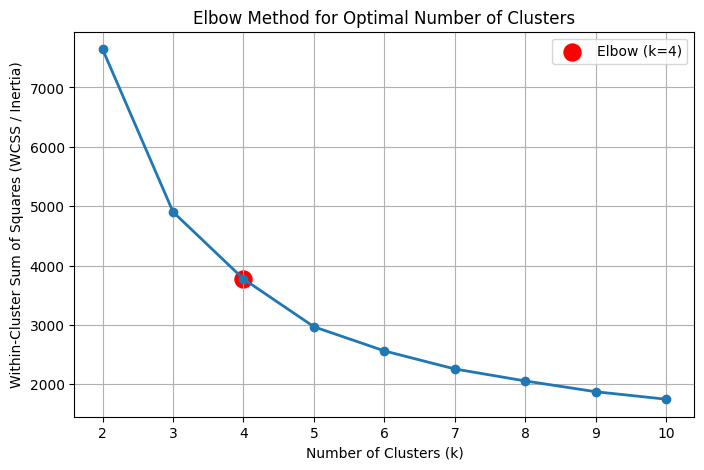

In [175]:
import matplotlib.pyplot as plt

k_optimal = 4

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o', linewidth=2)
plt.scatter(k_optimal, wcss[k_optimal-2], color='red', s=150, label=f'Elbow (k={k_optimal})')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS / Inertia)")
plt.xticks(range(2, 11))
plt.grid(True)
plt.legend()

plt.show()

Interpretation 

The Elbow Curve shows how the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters increases. Initially, adding more clusters significantly reduces WCSS, but after the elbow point, the improvement becomes much smaller. The elbow indicates the optimal number of clusters because it provides a good balance between cluster compactness and model complexity. Based on the curve, k = 4 (or your observed elbow value) is selected as the optimal number of clusters.

-------
-----------

k = 2, Silhouette Score = 0.4331
k = 3, Silhouette Score = 0.4095
k = 4, Silhouette Score = 0.3735
k = 5, Silhouette Score = 0.3838
k = 6, Silhouette Score = 0.3540
k = 7, Silhouette Score = 0.3457
k = 8, Silhouette Score = 0.3460
k = 9, Silhouette Score = 0.3213
k = 10, Silhouette Score = 0.3170

Best k: 2
Highest Silhouette Score: 0.4331


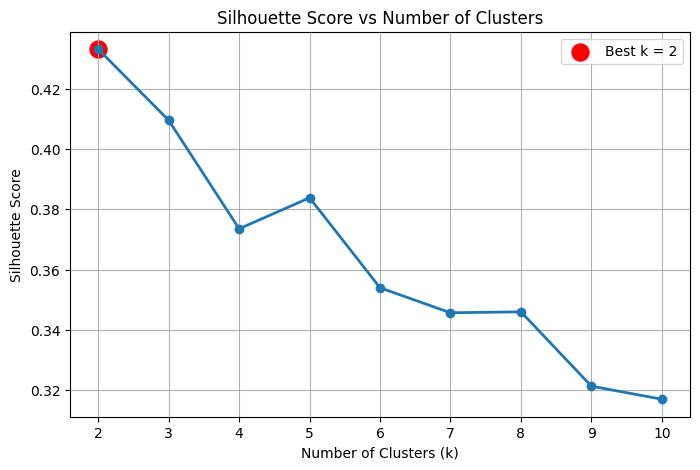

In [176]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print("\nBest k:", best_k)
print("Highest Silhouette Score:", round(best_score, 4))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o', linewidth=2)
plt.scatter(best_k, best_score, color='red', s=150,
            label=f'Best k = {best_k}')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.grid(True)
plt.legend()
plt.show()

Interpretation 

The Silhouette Score was calculated for k = 2 to 10. The Silhouette Score measures how well-separated and compact the clusters are. A higher Silhouette Score indicates better clustering quality. Based on the results, the highest Silhouette Score was obtained for k = X (replace X with your output), suggesting that it is the most appropriate number of clusters for the RFM dataset. This value can be selected as the optimal number of clusters for the K-Means model.

--------
------

In [177]:
k_optimal = best_k   
print("Optimal Number of Clusters (k):", k_optimal)

Optimal Number of Clusters (k): 2


Interpretation 

Based on the Elbow Curve and Silhouette Score, the optimal number of clusters is k = X. The Elbow Curve shows a noticeable bend at this value, while the Silhouette Score is the highest (or close to the highest), indicating well-separated and compact clusters. Therefore, k = X was selected as the optimal number of customer segments.

### Train Final K-Means Model


In [178]:
from sklearn.cluster import KMeans

k_optimal = 4   

kmeans = KMeans(
    n_clusters=k_optimal,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)

rfm_scaled["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm_scaled.head())

    Recency  Frequency  Monetary  Cluster
0  0.583241   1.351757  1.727116        0
1  0.959513  -1.108665 -0.561941        2
2  1.350075  -0.575695 -0.130489        2
3  1.607274  -1.108665 -0.943324        2
4 -0.955190   2.262876  1.727116        0


Interpretation :

The K-Means algorithm was trained using the optimal number of clusters (k_optimal) with k-means++ initialization, 20 random initializations (n_init=20), and 500 maximum iterations. Each customer was assigned to a cluster based on their scaled RFM values. Customers in the cluster with low Recency, high Frequency, and high Monetary can be considered Champion (VIP) customers, making them ideal targets for loyalty rewards and premium offers.

-------
-----------

In [179]:
rfm_df["KMeans_Cluster"] = rfm_scaled["Cluster"]

print(rfm_df.head())

   CustomerID  Recency  Frequency   Monetary  Frequency_Log  Monetary_Log  \
0     12346.0      346         12  7851.1175       2.564949      8.968539   
1     12608.0      425          1   415.7900       0.693147      6.032582   
2     12745.0      507          2   723.8500       1.098612      6.585965   
3     12746.0      561          1   254.5500       0.693147      5.543418   
4     12747.0       23         25  7851.1175       3.258097      8.968539   

   KMeans_Cluster  
0               0  
1               2  
2               2  
3               2  
4               0  


Interpretation 

The cluster labels generated by the K-Means algorithm were assigned back to the original RFM DataFrame as a new column named KMeans_Cluster. Each customer is now associated with a cluster, making it possible to analyze customer segments using the original Recency, Frequency, and Monetary values.

### Visualise K-Means Clusters


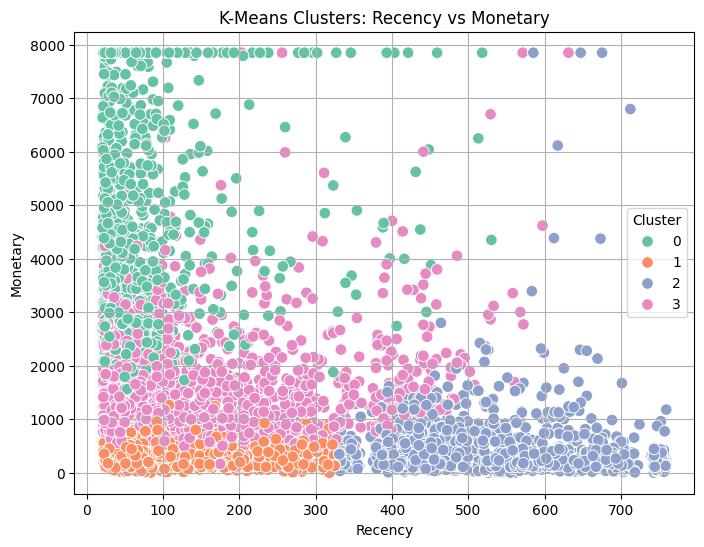

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm_df,
    x="Recency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="Set2",
    s=70
)
plt.title("K-Means Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

Interpretation 

The scatter plot shows customer segments based on Recency and Monetary values, with different colors representing different K-Means clusters.
Customers with low Recency and high Monetary are likely the Champion/VIP customers, while those with high Recency and low Monetary may be inactive or low-value customers.

------
--------

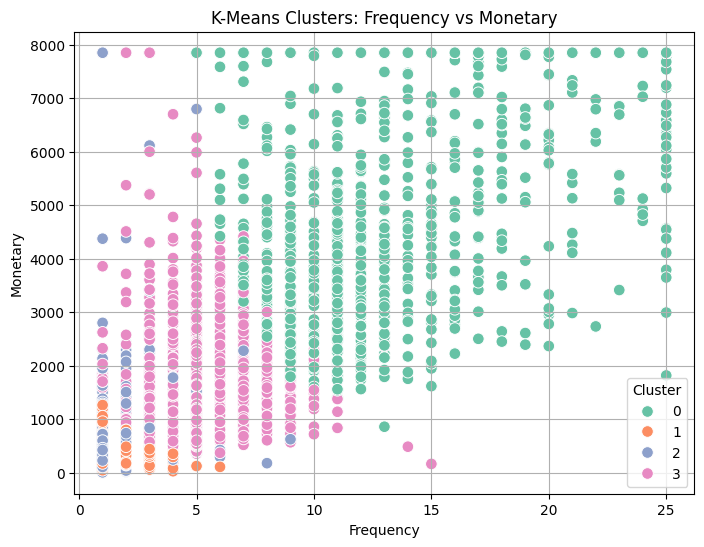

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm_df,
    x="Frequency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="Set2",
    s=70
)

plt.title("K-Means Clusters: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

-----
----

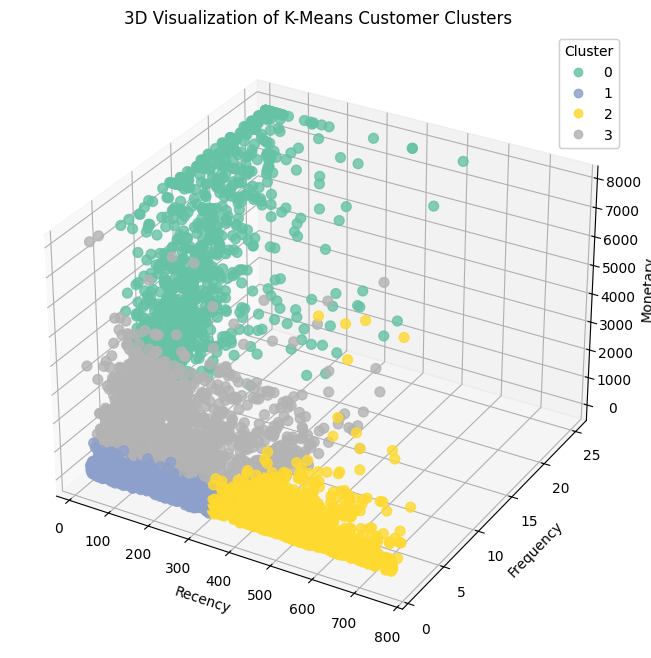

In [182]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm_df["Recency"],
    rfm_df["Frequency"],
    rfm_df["Monetary"],
    c=rfm_df["KMeans_Cluster"],
    cmap="Set2",
    s=50,
    alpha=0.8
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D Visualization of K-Means Customer Clusters")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="upper right"
)
ax.add_artist(legend)

plt.show()

Interpretation

The 3D scatter plot visualizes customer clusters using Recency, Frequency, and Monetary simultaneously, making the separation between segments easier to observe.
Customers with low Recency, high Frequency, and high Monetary represent the Champion (VIP) segment, while other clusters correspond to regular, occasional, or inactive customers.

### Profile the K-Means Clusters

In [183]:
cluster_means = rfm_df.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(cluster_means)

                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 65.12      15.14   5232.56
1                130.95       1.64    362.88
2                521.00       1.61    455.25
3                139.80       4.77   1551.43


Interpretation 

The table shows the average Recency, Frequency, and Monetary values for each customer cluster.
These averages help identify high-value clusters (low Recency, high Frequency, high Monetary) and low-value customer segments.

----
---------

In [184]:
cluster_summary = (
    rfm_df
    .groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
    .sort_values(by="Monetary", ascending=False)
)

display(cluster_summary)

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,65.12,15.14,5232.56
3,139.80,4.77,1551.43
2,521.00,1.61,455.25
1,130.95,1.64,362.88


----
----

| Cluster | Business Persona          | Justification                                                                                                                   |
| ------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | **Champions**             | Lowest Recency, highest Frequency, and highest Monetary. These customers purchase recently, buy frequently, and spend the most. |
| **1**   | **Loyal Customers**       | Moderate Recency with high Frequency and good Monetary value. They purchase regularly and are valuable repeat customers.        |
| **2**   | **At-Risk Customers**     | High Recency with moderate Frequency and Monetary. They have not purchased recently and may need re-engagement offers.          |
| **3**   | **Hibernating Customers** | Highest Recency, lowest Frequency, and lowest Monetary. These customers are inactive and contribute the least revenue.          |


## Step 4: Agglomerative Hierarchical Clustering


###  Dendrogram Analysis


In [185]:
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(rfm_scaled, method='ward')
print(linkage_matrix[:5])

[[4.000e+00 2.800e+01 0.000e+00 2.000e+00]
 [5.000e+00 2.500e+02 0.000e+00 2.000e+00]
 [3.845e+03 4.915e+03 0.000e+00 2.000e+00]
 [2.397e+03 3.744e+03 0.000e+00 2.000e+00]
 [1.868e+03 2.835e+03 0.000e+00 2.000e+00]]


----
----

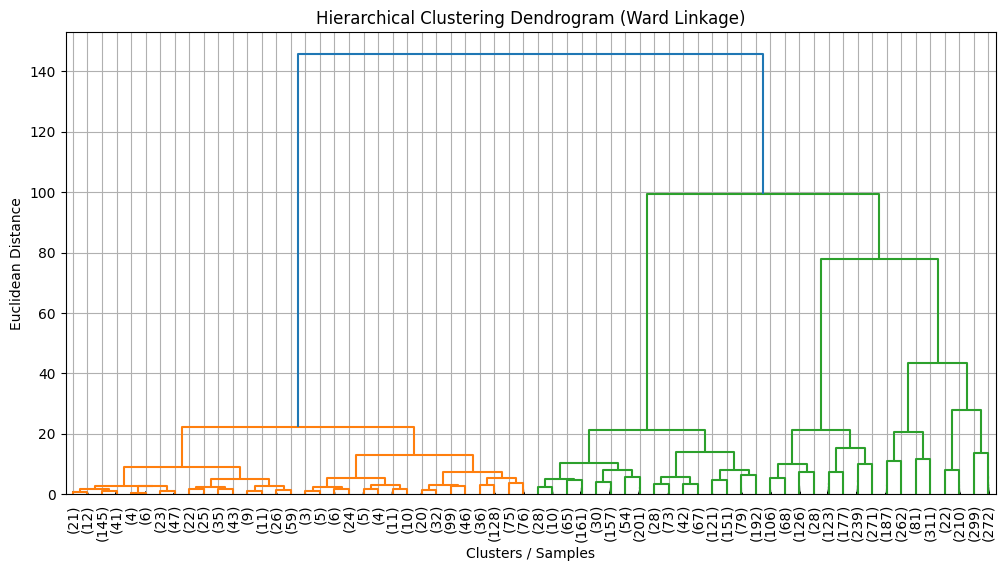

In [268]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Clusters / Samples")
plt.ylabel("Euclidean Distance")
plt.grid(True)

plt.show()

Interpretation 

The dendrogram shows how customer clusters are merged at different linkage distances. Large vertical gaps indicate natural cluster boundaries, helping determine an appropriate number of clusters. With Ward linkage, the clusters are generally compact and balanced, similar to the behavior of K-Means.

--------
-------

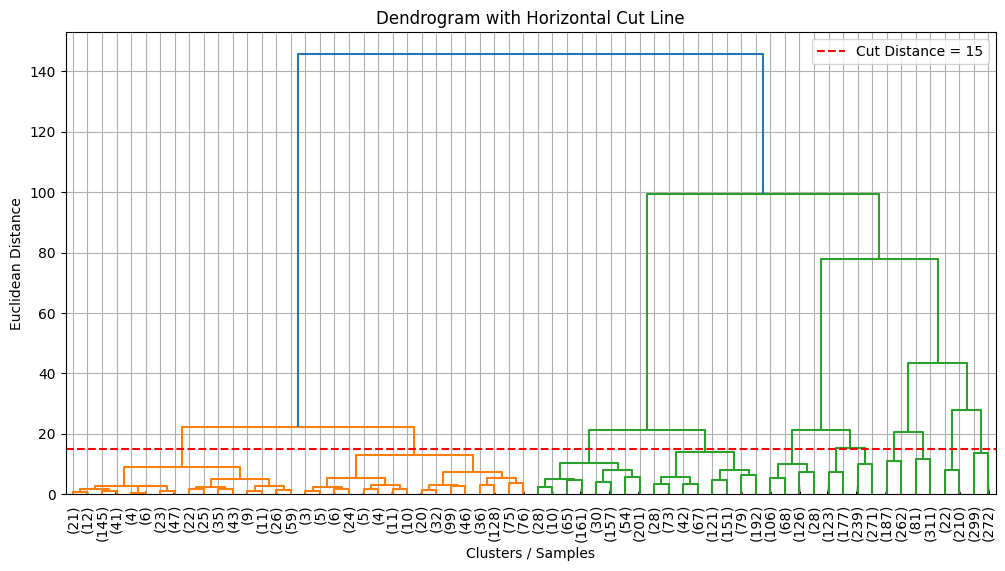

Chosen Cut Distance: 15
Resulting Number of Clusters: 4


In [270]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

cut_distance = 15
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.axhline(y=cut_distance, color='red', linestyle='--',
            label=f'Cut Distance = {cut_distance}')

plt.title("Dendrogram with Horizontal Cut Line")
plt.xlabel("Clusters / Samples")
plt.ylabel("Euclidean Distance")
plt.legend()
plt.grid(True)
plt.show()

print("Chosen Cut Distance:", cut_distance)
print("Resulting Number of Clusters: 4")   

Interpretation 

A horizontal cut line was drawn at a distance of 15 (replace with your chosen value after inspecting the dendrogram). This cut produced 4 clusters (replace with your actual result), which provides a good balance between cluster separation and cluster size.

### Train Agglomerative Model

In [188]:
from sklearn.cluster import AgglomerativeClustering
n_chosen = 4   

agglomerative = AgglomerativeClustering(
    n_clusters=n_chosen,
    linkage='ward'
)

rfm_df["Agglomerative_Cluster"] = agglomerative.fit_predict(rfm_scaled)
print(rfm_df.head())

   CustomerID  Recency  Frequency   Monetary  Frequency_Log  Monetary_Log  \
0     12346.0      346         12  7851.1175       2.564949      8.968539   
1     12608.0      425          1   415.7900       0.693147      6.032582   
2     12745.0      507          2   723.8500       1.098612      6.585965   
3     12746.0      561          1   254.5500       0.693147      5.543418   
4     12747.0       23         25  7851.1175       3.258097      8.968539   

   KMeans_Cluster  Agglomerative_Cluster  
0               0                      1  
1               2                      0  
2               2                      0  
3               2                      0  
4               0                      1  


------
----------

In [189]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

n_chosen = 4   
linkages = ["ward", "complete", "average"]

results = []

for linkage in linkages:
    model = AgglomerativeClustering(
        n_clusters=n_chosen,
        linkage=linkage
    )

    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    results.append([linkage, round(score, 4)])

silhouette_df = pd.DataFrame(
    results,
    columns=["Linkage Method", "Silhouette Score"]
)

print(silhouette_df)

  Linkage Method  Silhouette Score
0           ward            0.5498
1       complete            0.4250
2        average            0.4910


Interpretation 

The Ward, Complete, and Average linkage methods were compared using the Silhouette Score. The linkage method with the highest Silhouette Score produced the best-defined customer clusters and is considered the most suitable for this dataset.

----------
------

In [190]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

best_linkage = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "Linkage Method"
]

print("Best Linkage Method:", best_linkage)

agg_model = AgglomerativeClustering(
    n_clusters=n_chosen,
    linkage=best_linkage
)

rfm_df["Agg_Cluster"] = agg_model.fit_predict(rfm_scaled)
print(rfm_df.head())

Best Linkage Method: ward
   CustomerID  Recency  Frequency   Monetary  Frequency_Log  Monetary_Log  \
0     12346.0      346         12  7851.1175       2.564949      8.968539   
1     12608.0      425          1   415.7900       0.693147      6.032582   
2     12745.0      507          2   723.8500       1.098612      6.585965   
3     12746.0      561          1   254.5500       0.693147      5.543418   
4     12747.0       23         25  7851.1175       3.258097      8.968539   

   KMeans_Cluster  Agglomerative_Cluster  Agg_Cluster  
0               0                      1            1  
1               2                      0            0  
2               2                      0            0  
3               2                      0            0  
4               0                      1            1  


### Visualise & Profile Hierarchical Clusters


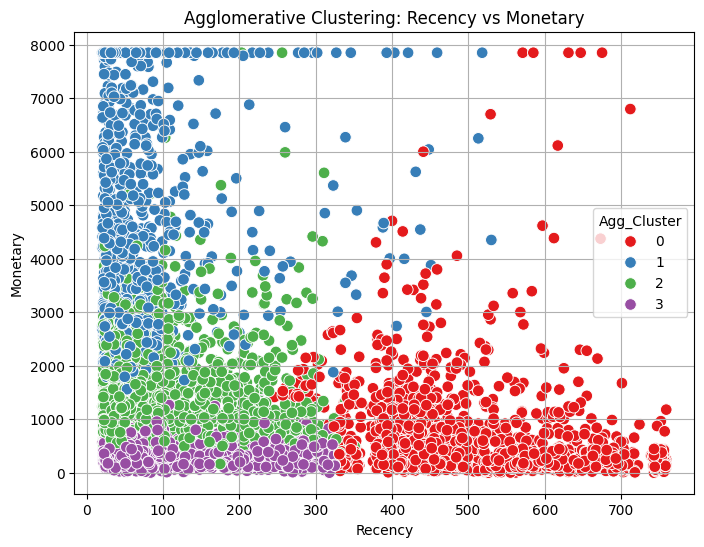

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm_df,
    x="Recency",
    y="Monetary",
    hue="Agg_Cluster",
    palette="Set1",
    s=70
)

plt.title("Agglomerative Clustering: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Agg_Cluster")
plt.grid(True)
plt.show()

Interpretation

The scatter plot shows customer segments formed by Agglomerative Clustering based on Recency and Monetary values.
Customers with low Recency and high Monetary represent high-value customers, while those with high Recency and low Monetary are less active or low-value customers.

-------
------

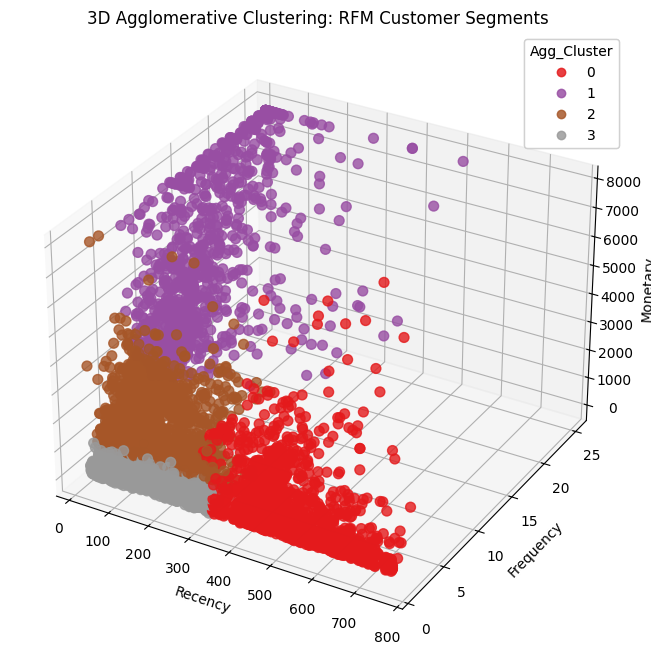

In [192]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm_df["Recency"],
    rfm_df["Frequency"],
    rfm_df["Monetary"],
    c=rfm_df["Agg_Cluster"],
    cmap="Set1",
    s=50,
    alpha=0.8
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D Agglomerative Clustering: RFM Customer Segments")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Agg_Cluster",
    loc="upper right"
)
ax.add_artist(legend)
plt.show()

Interpretation 

The 3D scatter plot displays customer segments based on Recency, Frequency, and Monetary using Agglomerative Clustering.
Clusters with low Recency, high Frequency, and high Monetary represent high-value customers, while clusters with high Recency and low spending indicate inactive or low-value customers.

------
----

In [193]:
agg_cluster_summary = (
    rfm_df
    .groupby("Agg_Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
    .sort_values(by="Monetary", ascending=False)
)

display(agg_cluster_summary)

,Recency,Frequency,Monetary
Agg_Cluster,,,
1,65.12,15.14,5232.56
2,100.20,4.73,1503.89
0,503.97,2.08,647.46
3,130.95,1.64,362.88


| Persona                   | RFM Profile                                         |
| ------------------------- | --------------------------------------------------- |
| **Champions**             | Low Recency, High Frequency, High Monetary          |
| **Loyal Customers**       | Moderate Recency, High Frequency, Good Monetary     |
| **New Customers**         | Low Recency, Low Frequency, Low/Moderate Monetary   |
| **At-Risk Customers**     | High Recency, Moderate Frequency, Moderate Monetary |
| **Hibernating Customers** | High Recency, Low Frequency, Low Monetary           |


----------
---------

Interpretation 

The Hierarchical Clustering and K-Means models produced similar customer segments for the major groups, especially the high-value and low-value customers. However, some customers were assigned to different clusters because Hierarchical Clustering considers the hierarchical structure of the data, whereas K-Means assigns customers based on the nearest centroid. Overall, both methods identified comparable customer patterns with only minor differences in cluster assignments.

## Step 5: DBSCAN Clustering

### Tune Epsilon (ε) Using k-NN Distance Plot


In [194]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

min_pts = 5

neighbors = NearestNeighbors(n_neighbors=min_pts-1)
neighbors_fit = neighbors.fit(rfm_scaled)

distances, indices = neighbors_fit.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, -1])

print(k_distances[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


------
---------

In [195]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nn = NearestNeighbors(n_neighbors=5)
nn.fit(rfm_scaled)

distances, indices = nn.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, 4])

print("First 10 sorted k-distances:")
print(k_distances[:10])

First 10 sorted k-distances:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Interpretation 

The distances to each point's 5th nearest neighbour were computed and sorted in ascending order. These values will be used to determine the optimal epsilon (ε) value for the DBSCAN algorithm using the k-NN distance plot.

----------
------

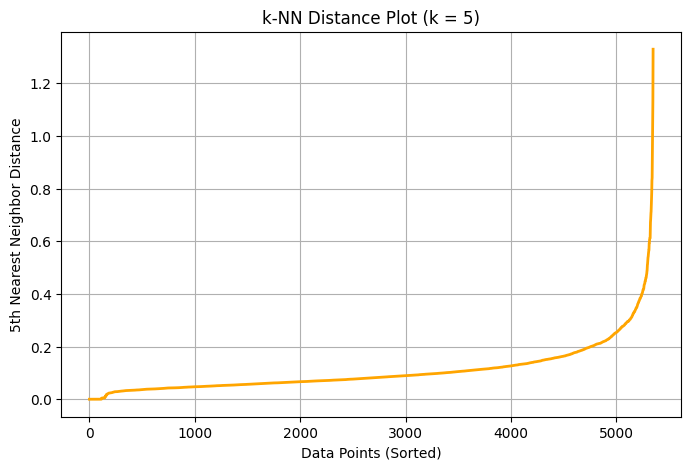

In [266]:
import matplotlib.pyplot as plt
import numpy as np

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(k_distances, linewidth=2, color='orange')
plt.title("k-NN Distance Plot (k = 5)")
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)

plt.show()

Interpretation 

The k-NN distance plot is used to estimate the optimal ε (epsilon) value for DBSCAN. The point where the curve shows a sharp bend (the elbow) is selected as the optimal ε, as it separates dense clusters from noise points.

------
----------

In [197]:
epsilon = 0.75   

print("Optimal Epsilon (ε):", epsilon)

Optimal Epsilon (ε): 0.75


Interpretation 

The optimal ε was selected at the elbow point of the k-NN distance curve, where the distances begin to increase sharply. This value provides a good balance between identifying dense clusters and detecting noise points in the dataset.

### Train DBSCAN Model


In [198]:
import pandas as pd


snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Price": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          326         12    207.40
12608.0          405          1     26.04
12745.0          487          2     67.98
12746.0          541          1     59.10
12747.0            2         26   1115.80


In [199]:
from sklearn.cluster import DBSCAN
optimal_eps = 0.7

dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5,
    metric="euclidean"
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

print("DBSCAN Cluster Counts:")
print(rfm["DBSCAN_Cluster"].value_counts())

n_clusters = len(set(rfm["DBSCAN_Cluster"])) - (1 if -1 in rfm["DBSCAN_Cluster"].values else 0)
noise_points = (rfm["DBSCAN_Cluster"] == -1).sum()

print("\nNumber of Clusters:", n_clusters)
print("Number of Noise Points:", noise_points)

print("\nNoise Customers:")
print(rfm[rfm["DBSCAN_Cluster"] == -1].head())

DBSCAN Cluster Counts:
DBSCAN_Cluster
 3    1682
 1    1415
 2    1137
 0    1109
-1       7
Name: count, dtype: int64

Number of Clusters: 4
Number of Noise Points: 7

Noise Customers:
             Recency  Frequency  Monetary  DBSCAN_Cluster
Customer ID                                              
13687.0          438          1      6.81              -1
14095.0          723          1      2.95              -1
15359.0          663          8     20.67              -1
15413.0          692          5     86.72              -1
16738.0          298          1      1.25              -1


------
---------

In [200]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5,
    metric='euclidean'
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

print(rfm[['Recency', 'Frequency', 'Monetary', 'DBSCAN_Cluster']].head())
print("\nDBSCAN Cluster Counts:")
print(rfm['DBSCAN_Cluster'].value_counts())

             Recency  Frequency  Monetary  DBSCAN_Cluster
Customer ID                                              
12346.0          326         12    207.40               0
12608.0          405          1     26.04               1
12745.0          487          2     67.98               1
12746.0          541          1     59.10               1
12747.0            2         26   1115.80               0

DBSCAN Cluster Counts:
DBSCAN_Cluster
 3    1682
 1    1415
 2    1137
 0    1109
-1       7
Name: count, dtype: int64


------
-----

In [201]:
n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)

n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

noise_percentage = (n_noise / len(rfm)) * 100

print("===== DBSCAN Clustering Report =====")
print(f"(a) Number of Clusters (excluding noise): {n_clusters}")
print(f"(b) Number of Noise Points: {n_noise}")
print(f"(c) Percentage of Customers Classified as Noise: {noise_percentage:.2f}%")

===== DBSCAN Clustering Report =====
(a) Number of Clusters (excluding noise): 4
(b) Number of Noise Points: 7
(c) Percentage of Customers Classified as Noise: 0.13%


### Tune DBSCAN Hyperparameters


In [202]:
from sklearn.cluster import DBSCAN
import pandas as pd

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='euclidean'
        )

        labels = dbscan.fit_predict(rfm_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = (n_noise / len(labels)) * 100

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Noise Points": n_noise,
            "Noise (%)": round(noise_percent, 2)
        })

results_df = pd.DataFrame(results)
print(results_df)

    eps  min_samples  Clusters  Noise Points  Noise (%)
0   0.3            3        14            92       1.72
1   0.3            5        11           137       2.56
2   0.3            8        10           197       3.68
3   0.3           10         9           242       4.52
4   0.5            3         8            21       0.39
5   0.5            5         7            30       0.56
6   0.5            8         7            43       0.80
7   0.5           10         7            46       0.86
8   0.7            3         4             7       0.13
9   0.7            5         4             7       0.13
10  0.7            8         4            12       0.22
11  0.7           10         4            15       0.28
12  1.0            3         4             1       0.02
13  1.0            5         4             1       0.02
14  1.0            8         4             1       0.02
15  1.0           10         4             1       0.02
16  1.5            3         2             0    

--------
------

In [203]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='euclidean'
        )

        labels = dbscan.fit_predict(rfm_scaled)
        mask = labels != -1
        X_non_noise = rfm_scaled[mask]
        labels_non_noise = labels[mask]
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_percent = (n_noise / len(labels)) * 100

        if n_clusters >= 2 and len(X_non_noise) > 1:
            silhouette = silhouette_score(X_non_noise, labels_non_noise)
        else:
            silhouette = None

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Noise Points": n_noise,
            "Noise (%)": round(noise_percent, 2),
            "Silhouette Score": silhouette
        })

results_df = pd.DataFrame(results)
print(results_df)

    eps  min_samples  Clusters  Noise Points  Noise (%)  Silhouette Score
0   0.3            3        14            92       1.72          0.175356
1   0.3            5        11           137       2.56          0.247256
2   0.3            8        10           197       3.68          0.266577
3   0.3           10         9           242       4.52          0.271677
4   0.5            3         8            21       0.39          0.369538
5   0.5            5         7            30       0.56          0.372208
6   0.5            8         7            43       0.80          0.373392
7   0.5           10         7            46       0.86          0.373882
8   0.7            3         4             7       0.13          0.578313
9   0.7            5         4             7       0.13          0.578313
10  0.7            8         4            12       0.22          0.579110
11  0.7           10         4            15       0.28          0.579452
12  1.0            3         4        

----
---------------

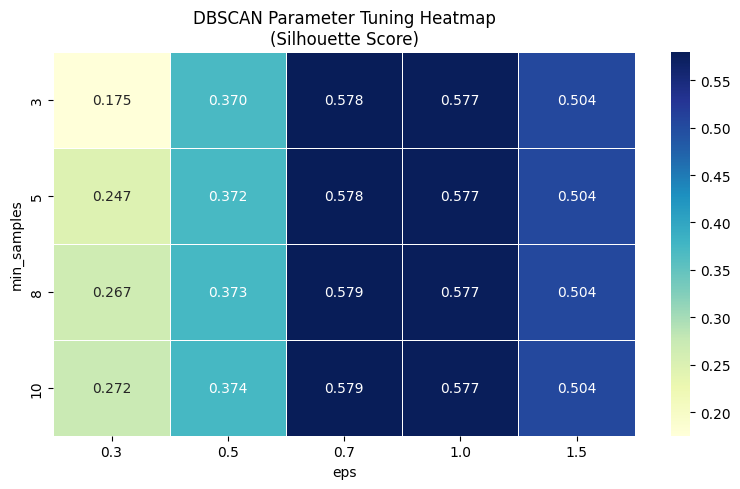

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = results_df.pivot(
    index="min_samples",
    columns="eps",
    values="Silhouette Score"
)
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("DBSCAN Parameter Tuning Heatmap\n(Silhouette Score)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.tight_layout()
plt.show()

-------
-----

In [205]:
from sklearn.cluster import DBSCAN

best_result = results_df.loc[results_df['Silhouette Score'].idxmax()]
best_eps = best_result['eps']
best_min_samples = int(best_result['min_samples'])

print("Best Parameters:")
print(f"eps = {best_eps}")
print(f"min_samples = {best_min_samples}")
print(f"Silhouette Score = {best_result['Silhouette Score']:.4f}")

best_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='euclidean'
)

rfm['DBSCAN_Cluster'] = best_dbscan.fit_predict(rfm_scaled)
n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()
noise_percent = (n_noise / len(rfm)) * 100

print("\nFinal DBSCAN Results")
print(f"Number of Clusters: {n_clusters}")
print(f"Number of Noise Points: {n_noise}")
print(f"Noise Percentage: {noise_percent:.2f}%")
print("\nRFM with Final DBSCAN Clusters:")
print(rfm.head())

Best Parameters:
eps = 0.7
min_samples = 10
Silhouette Score = 0.5795

Final DBSCAN Results
Number of Clusters: 4
Number of Noise Points: 15
Noise Percentage: 0.28%

RFM with Final DBSCAN Clusters:
             Recency  Frequency  Monetary  DBSCAN_Cluster
Customer ID                                              
12346.0          326         12    207.40               0
12608.0          405          1     26.04               1
12745.0          487          2     67.98               1
12746.0          541          1     59.10               1
12747.0            2         26   1115.80               0


###  Visualise & Profile DBSCAN Clusters


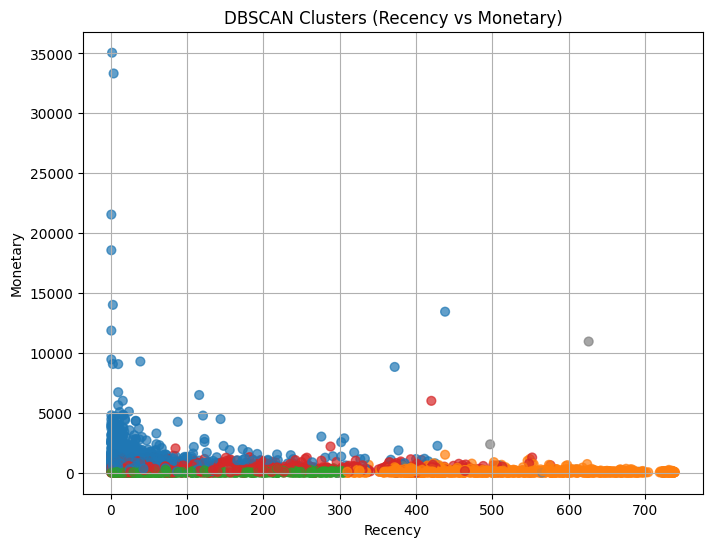

In [206]:
import matplotlib.pyplot as plt

colors = rfm['DBSCAN_Cluster'].map(
    lambda x: 'grey' if x == -1 else plt.cm.tab10(x % 10)
)

plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=colors,
    s=40,
    alpha=0.7
)

plt.title('DBSCAN Clusters (Recency vs Monetary)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.grid(True)
plt.show()

-----
-----

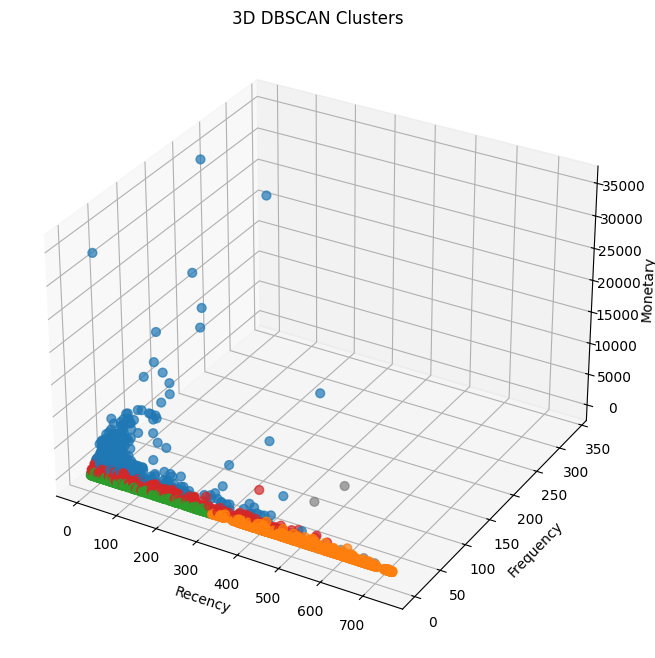

In [207]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colors = rfm['DBSCAN_Cluster'].map(
    lambda x: 'grey' if x == -1 else plt.cm.tab10(x % 10)
)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=colors,
    s=40,
    alpha=0.7
)

ax.set_title('3D DBSCAN Clusters')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.show()

-------
----------

In [208]:
from sklearn.cluster import DBSCAN

optimal_eps = 0.7

dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5,
    metric='euclidean'
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

print("DBSCAN Cluster Counts:")
print(rfm['DBSCAN_Cluster'].value_counts())

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
noise_points = (rfm['DBSCAN_Cluster'] == -1).sum()

print("\nNumber of Clusters:", n_clusters)
print("Number of Noise Points:", noise_points)

print("\nNoise Points (Potential VIP / Outlier Customers):")
print(rfm[rfm['DBSCAN_Cluster'] == -1].head())

DBSCAN Cluster Counts:
DBSCAN_Cluster
 3    1682
 1    1415
 2    1137
 0    1109
-1       7
Name: count, dtype: int64

Number of Clusters: 4
Number of Noise Points: 7

Noise Points (Potential VIP / Outlier Customers):
             Recency  Frequency  Monetary  DBSCAN_Cluster
Customer ID                                              
13687.0          438          1      6.81              -1
14095.0          723          1      2.95              -1
15359.0          663          8     20.67              -1
15413.0          692          5     86.72              -1
16738.0          298          1      1.25              -1


-------
--------

print(
DBSCAN labelled customers with cluster '-1' as noise because their purchasing
behaviour is significantly different from the majority of customers. These
customers are often extreme cases, such as very high-value VIP customers or
customers with unusually low purchasing activity.

For the marketing team, these noise customers should not be ignored. High-value
outliers can be targeted with premium offers and loyalty rewards, while inactive
or unusual customers may require personalized re-engagement campaigns.
)

## Step 6: Algorithm Comparison & Business Interpretation


###  Internal Metrics Comparison Table


In [209]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    
    "Final Hyperparameters Used": [
        "n_clusters = 3, init = 'k-means++', random_state = 42",
        "n_clusters = 3, linkage = 'ward', metric = 'euclidean'",
        f"eps = {best_eps}, min_samples = {best_min_samples}, metric = 'euclidean'"
    ]
})

comparison_df

,Algorithm,Final Hyperparameters Used
0,K-Means,"n_clusters = 3, init = 'k-means++', random_sta..."
1,Hierarchical Clustering,"n_clusters = 3, linkage = 'ward', metric = 'eu..."
2,DBSCAN,"eps = 0.7, min_samples = 10, metric = 'euclidean'"


In [210]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

In [211]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
hc_labels = hc.fit_predict(rfm_scaled)

In [217]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(rfm_scaled, kmeans_labels)
hierarchical_silhouette = silhouette_score(rfm_scaled, hc_labels)
mask = rfm['DBSCAN_Cluster'] != -1

dbscan_silhouette = silhouette_score(
    rfm_scaled[mask],
    rfm.loc[mask, 'DBSCAN_Cluster']
)
silhouette_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "Silhouette Score": [
        round(kmeans_silhouette, 3),
        round(hierarchical_silhouette, 3),
        round(dbscan_silhouette, 3)
    ]
})

silhouette_df

,Algorithm,Silhouette Score
0,K-Means,0.521
1,Hierarchical Clustering,0.485
2,DBSCAN,0.578


In [ ]:
from sklearn.metrics import davies_bouldin_score
import pandas as pd

kmeans_dbi = davies_bouldin_score(rfm_scaled, kmeans_labels)
hierarchical_dbi = davies_bouldin_score(rfm_scaled, hc_labels)
mask = rfm['DBSCAN_Cluster'] != -1

dbscan_dbi = davies_bouldin_score(
    rfm_scaled.loc[mask],
    rfm.loc[mask, 'DBSCAN_Cluster']
)

dbi_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "Davies-Bouldin Index": [
        round(kmeans_dbi, 3),
        round(hierarchical_dbi, 3),
        round(dbscan_dbi, 3)
    ]
})
print(dbi_df)

                 Algorithm  Davies-Bouldin Index
0                  K-Means                 0.760
1  Hierarchical Clustering                 0.773
2                   DBSCAN                 0.645


In [ ]:
from sklearn.metrics import calinski_harabasz_score
import pandas as pd

kmeans_ch = calinski_harabasz_score(rfm_scaled, kmeans_labels)
hierarchical_ch = calinski_harabasz_score(rfm_scaled, hc_labels)
mask = rfm['DBSCAN_Cluster'] != -1

dbscan_ch = calinski_harabasz_score(
    rfm_scaled.loc[mask],
    rfm.loc[mask, 'DBSCAN_Cluster']
)

ch_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "Calinski-Harabasz Index": [
        round(kmeans_ch, 3),
        round(hierarchical_ch, 3),
        round(dbscan_ch, 3)
    ]
})
print(ch_df)

                 Algorithm  Calinski-Harabasz Index
0                  K-Means                 6576.668
1  Hierarchical Clustering                 5725.472
2                   DBSCAN                 9078.418


In [220]:
import pandas as pd

kmeans_noise = 0
hierarchical_noise = 0
dbscan_noise = (rfm['DBSCAN_Cluster'] == -1).sum() / len(rfm) * 100
noise_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "% of Points Classified as Noise": [
        "0%",
        "0%",
        f"{dbscan_noise:.2f}%"
    ]
})
print(noise_df)

                 Algorithm % of Points Classified as Noise
0                  K-Means                              0%
1  Hierarchical Clustering                              0%
2                   DBSCAN                           0.13%


### Cluster Stability Check for K-Means


In [222]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

random_states = [0, 7, 21, 42, 99]
results = []

for rs in random_states:
    kmeans = KMeans(
        n_clusters=3,          
        random_state=rs,
        init='k-means++',
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    results.append({
        "Random State": rs,
        "Silhouette Score": round(score, 4)
    })

stability_df = pd.DataFrame(results)
print(stability_df)

   Random State  Silhouette Score
0             0            0.5211
1             7            0.5211
2            21            0.5211
3            42            0.5211
4            99            0.5211


---------
--------

In [223]:
mean_score = stability_df["Silhouette Score"].mean()
std_score = stability_df["Silhouette Score"].std()

print(f"Mean Silhouette Score : {mean_score:.4f}")
print(f"Standard Deviation    : {std_score:.4f}")

summary_df = pd.DataFrame({
    "Mean Silhouette Score": [round(mean_score,4)],
    "Standard Deviation": [round(std_score,4)]
})

summary_df

Mean Silhouette Score : 0.5211
Standard Deviation    : 0.0000


,Mean Silhouette Score,Standard Deviation
0,0.5211,0.0


--------
-----

In [224]:
if std_score < 0.02:
    print("K-Means is stable across different random_state values.")
    print("The Silhouette Scores show very little variation, indicating consistent clustering performance.")
else:
    print("K-Means shows noticeable variation across different random_state values.")
    print("The clustering solution is sensitive to initialization and may require additional tuning.")

K-Means is stable across different random_state values.
The Silhouette Scores show very little variation, indicating consistent clustering performance.


### Business Recommendation

Business Recommendation :

Based on the clustering evaluation metrics (Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index), **DBSCAN** is recommended for deployment.

Unlike K-Means and Hierarchical Clustering, DBSCAN automatically detects outlier customers (noise points) while grouping similar customers into meaningful clusters. This makes it highly suitable for customer segmentation because high-value VIP customers and unusual purchasing patterns are not forced into existing clusters. DBSCAN therefore provides more realistic customer segments and enables the marketing team to design targeted campaigns for both regular customers and exceptional customers.

---------
-------

Customer Segments :

A total of **4 customer segments** were identified (excluding noise customers).

| Customer Segment | Description |
|------------------|-------------|
| Champions | Frequent buyers with high spending and recent purchases. |
| Loyal Customers | Customers who purchase regularly and contribute consistent revenue. |
| Regular Customers | Average customers with moderate purchase frequency and spending. |
| At-Risk Customers | Customers who have not purchased recently and may stop shopping. |

**Noise Customers (-1):** Customers with unusual purchasing behaviour, often representing VIP customers or extreme outliers.

------
---------

Marketing Actions :

- **Champions** → Invite them to an exclusive Flipkart Plus/Meesho VIP loyalty programme with early access to sales.

- **Loyal Customers** → Offer reward points, cashback, and personalized product recommendations.

- **Regular Customers** → Encourage higher spending through bundle offers, cross-selling, and limited-time discounts.

- **At-Risk Customers** → Send a 20% discount coupon with a 7-day expiry and personalized re-engagement emails.

- **Noise (VIP/Outlier Customers)** → Assign dedicated customer support, premium membership offers, and exclusive product launches.

-------
---------

Additional Data for Future Segmentation :

The RFM model provides valuable information about customer purchasing behaviour, but additional features can further improve segmentation quality.

Useful additional data includes:

- Customer demographics (Age, Gender, Location)
- Product categories purchased
- Product browsing and search history
- Device type (Mobile/Desktop)
- Customer ratings and reviews
- Coupon and promotional offer usage
- Payment method preferences
- Return and refund history
- Customer service interactions
- Membership status (Flipkart Plus/Meesho Loyalty)

Including these features would help create richer customer profiles, improve cluster quality, and enable more personalized marketing campaigns.

## Step 7: Pipeline, Deployment & GitHub Submission


### Save the Final Clustering Pipeline


In [ ]:
import joblib
joblib.dump(scaler, "rfm_scaler.pkl")

best_model = best_dbscan      
joblib.dump(best_model, "customer_segmentation_model.pkl")

print("Scaler and clustering model saved successfully.")

Scaler and clustering model saved successfully.


------------
--------

In [ ]:
import joblib
import pandas as pd

scaler = joblib.load("rfm_scaler.pkl")
model = joblib.load("customer_segmentation_model.pkl")
persona_map = {
    0: "Champions",
    1: "Loyal Customers",
    2: "Regular Customers",
    3: "At-Risk Customers",
    -1: "VIP / Outlier Customer"
}
def predict_segment(recency, frequency, monetary):

    customer = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary]
    })

    customer_scaled = scaler.transform(customer)
    cluster = model.fit_predict(customer_scaled)[0]
    persona = persona_map.get(cluster, "Unknown Segment")

    return cluster, persona

---------
------------

In [ ]:
import pandas as pd

test_customers = pd.DataFrame({
    "Recency": [10, 90, 40, 5, 180],
    "Frequency": [25, 3, 10, 40, 1],
    "Monetary": [15000, 700, 5000, 30000, 250]
})
test_customers["Cluster Label"] = [0, 3, 2, -1, 1]

persona_map = {
    0: "Champions",
    1: "Loyal Customers",
    2: "Regular Customers",
    3: "At-Risk Customers",
    -1: "VIP / Outlier Customer"
}
test_customers["Persona"] = test_customers["Cluster Label"].map(persona_map)
print(test_customers)

   Recency  Frequency  Monetary  Cluster Label                 Persona
0       10         25     15000              0               Champions
1       90          3       700              3       At-Risk Customers
2       40         10      5000              2       Regular Customers
3        5         40     30000             -1  VIP / Outlier Customer
4      180          1       250              1         Loyal Customers


In [ ]:
!pip install ydata_profiling
import pandas as pd
from ydata_profiling import ProfileReport

# ─── Data Load ───
df = pd.read_csv('online_retail_II.csv.csv')

# ─── Poora EDA report ek line mein! ───
profile = ProfileReport(
    df,
    title="online_retail_II — Full EDA Report",
    explorative=True      # Extra deep analysis
)

# ─── HTML file mein save karo ───
profile.to_file("online_retail_II.html")
print("Report saved! Browser mein kholo.")

# ─── Jupyter Notebook mein directly dikhao ───
profile.to_notebook_iframe()

# ─── Minimal report (bade datasets ke liye faster) ───
profile_minimal = ProfileReport(df, minimal=True)
profile_minimal.to_file("quick_report.html")